In [1]:
import dask.dataframe as dd
import dask.array as da
import dask
import numpy as np
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
import time

In [2]:
s = 100000
L = 100000000
a = np.arange(L)
big = np.zeros(s)

1  chunks
remainder 0
0.0  seconds
---


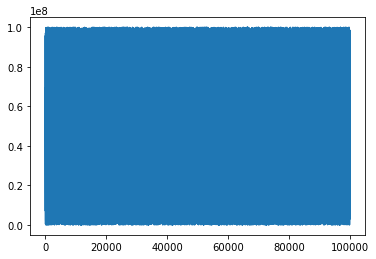

10  chunks
remainder 0
0.0  seconds
---


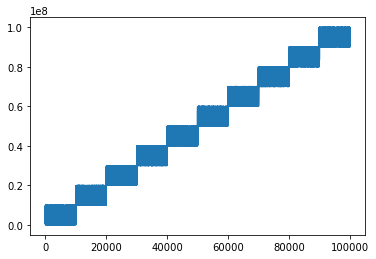

100  chunks
remainder 0
0.0  seconds
---


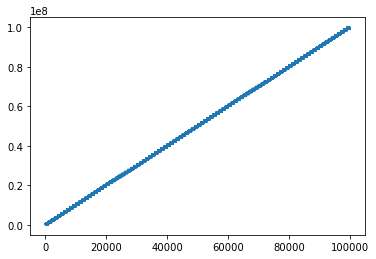

1000  chunks
remainder 0
0.0  seconds
---


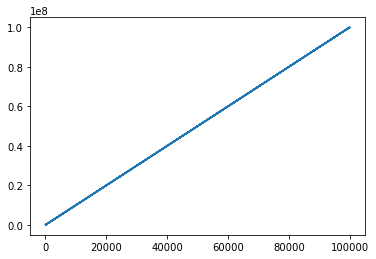

10000  chunks
remainder 0
0.0  seconds
---


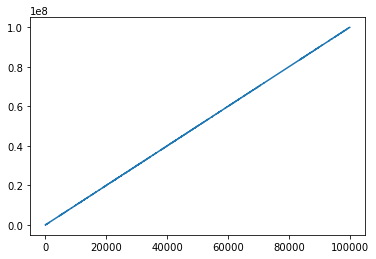

In [3]:
# big = np.zeros(s)
for N in range(5):
    big = np.zeros(s)
    n = 10**N
    start = time.time()
    print(n," chunks\nremainder",s%n)
    for i in range(n):
        big[s//n*i:s//n*(i+1)] = np.random.choice(a[int(L/n*i):int(L/n*(i+1))], s//n, replace=True)
    print((time.time()-start)*10//10," seconds\n---")
    plt.plot(big)
    plt.show()

In [4]:
%%timeit
if n < 10000:
    0
    if n > 1000:
        0

37.6 ns ± 2.07 ns per loop (mean ± std. dev. of 7 runs, 10000000 loops each)


In [5]:
times = np.zeros((20,3))
times[0] = [1, 1170, 342]
times[1] = [2, 946, 220]
times[2] = [4, 902, 196]
times[3] = [8, 847, 212]
times[4] = [16, 718, 179]
times[5] = [32, 771, 265]
times[6] = [64, 482, 191]
times[7] = [256, 280, 52.7]
times[8] = [1024, 361, 71.5]

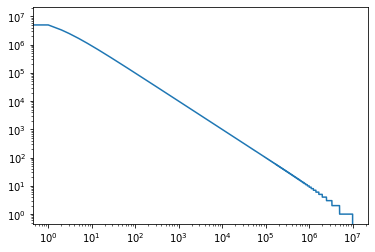

In [6]:
L = 10000000
Max = 10000
s=np.arange(L)
plt.plot((L-Max)//(s+1))
plt.yscale('log')
plt.xscale('log')

In [7]:
(25-np.array([17,1,2,3,4,5,6])-1)/(5-1)

array([1.75, 5.75, 5.5 , 5.25, 5.  , 4.75, 4.5 ])

In [8]:
arr0 = dd.read_csv('../dmpc/r1/pressure-tensor.xvg', skiprows = 33, header=None, delim_whitespace=True, sample=3300000)

In [9]:
arr0.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.0,311.097290,59.331459,-45.010242,18.823420,-44.083313,35.282639,316.700134,20.125151,315.188049,56.849167
1,2.0,311.226868,-52.248123,-16.772848,-99.244408,-17.765566,204.537720,-16.148245,-100.923302,-15.057701,191.339890
2,4.0,311.587463,-230.264603,63.565117,-10.174314,61.410522,39.967865,25.077406,-10.532000,26.330414,297.512329
3,6.0,312.801849,182.588135,-162.219559,-28.434866,-160.977158,-23.008495,-9.890800,-28.224962,-11.505493,39.299557
4,8.0,310.813446,91.957085,-104.257111,110.495293,-104.638176,151.074554,-132.606369,109.375931,-133.124130,9.941408


In [10]:
arr0.columns = ['t','temp','xx','xy','xz','yx','yy','yz','zx','zy','zz']

In [11]:
np.array(arr0['xy'])

array([-45.010242, -16.772848,  63.565117, ...,  -1.923454,  29.787161,
       143.516693])

In [12]:
arr0.head()

,t,temp,xx,xy,xz,yx,yy,yz,zx,zy,zz
0,0.0,311.097290,59.331459,-45.010242,18.823420,-44.083313,35.282639,316.700134,20.125151,315.188049,56.849167
1,2.0,311.226868,-52.248123,-16.772848,-99.244408,-17.765566,204.537720,-16.148245,-100.923302,-15.057701,191.339890
2,4.0,311.587463,-230.264603,63.565117,-10.174314,61.410522,39.967865,25.077406,-10.532000,26.330414,297.512329
3,6.0,312.801849,182.588135,-162.219559,-28.434866,-160.977158,-23.008495,-9.890800,-28.224962,-11.505493,39.299557
4,8.0,310.813446,91.957085,-104.257111,110.495293,-104.638176,151.074554,-132.606369,109.375931,-133.124130,9.941408


In [13]:
arr0.t.loc[0].compute()

0    0.0
Name: t, dtype: float64

In [14]:
(arr0['xx'].loc[0].values-arr0['xx'].loc[1].values).compute()[0]

111.57958199999999

In [15]:
arr0.loc[10,'temp'].compute()-arr0.loc[11,'temp'].compute()

10   NaN
11   NaN
Name: temp, dtype: float64

In [16]:
arr0['temp'].sem()/arr0['temp'].size

dd.Scalar<truediv..., dtype=float64>

In [17]:
arr0[['xy','yx']].mean(axis=1).compute()

0        -44.546778
1        -17.269207
2         62.487820
3       -161.598359
4       -104.447643
            ...    
97996     -8.141260
97997    224.192101
97998     -0.709892
97999     28.923315
98000    143.557266
Length: 98001, dtype: float64

In [18]:
np.zeros_like(arr0.xy)

array([0., 0., 0., ..., 0., 0., 0.])

In [19]:
len(arr0.xy)

98001

In [20]:
arr0.xy

Dask Series Structure:
npartitions=1
    float64
        ...
Name: xy, dtype: float64
Dask Name: getitem, 3 tasks

In [21]:
cheese = arr0[['xy','yx']].mean(axis=1)

In [22]:
cheese

Dask Series Structure:
npartitions=1
    float64
        ...
dtype: float64
Dask Name: dataframe-mean, 4 tasks

In [23]:
cheese.compute()

0        -44.546778
1        -17.269207
2         62.487820
3       -161.598359
4       -104.447643
            ...    
97996     -8.141260
97997    224.192101
97998     -0.709892
97999     28.923315
98000    143.557266
Length: 98001, dtype: float64

In [24]:
cheese -= cheese.mean()

In [25]:
cheese.compute()

0        -44.400124
1        -17.122554
2         62.634473
3       -161.451705
4       -104.300990
            ...    
97996     -7.994606
97997    224.338754
97998     -0.563239
97999     29.069968
98000    143.703919
Length: 98001, dtype: float64

In [26]:
cheese.mean().compute()

8.445221769301994e-16

In [27]:
bigpressure = arr0

In [28]:
bigpressure["temp"].mean().compute()

312.0143459276844

In [29]:
bigpressure["temp"].sem().compute()

0.003500619172192214

In [30]:
stress = cheese

In [31]:
len(stress)

98001

In [32]:
sa = np.zeros_like(stress)

(0.0, 1000.0)

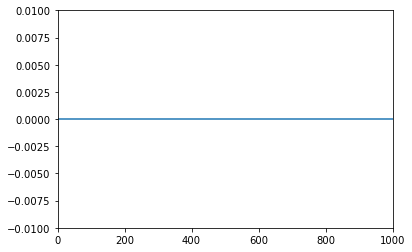

In [33]:
plt.plot(sa)
plt.ylim(-0.01,0.01)
plt.xlim(0,1000)

In [34]:
def autocor(arr, tau):
    if tau > len(arr):
        return "tau set too large"
    aaa = arr.loc[tau:].values * arr.loc[:len(stress) - tau - 1].values
    # if tau % 100 == 0:
    #     print(f"\r{(tau/len(arr))*100:6.2f}", "%   ", end="")
    return(aaa.mean().compute(),((aaa.var()/(len(arr)-tau))**0.5).compute())
autocor(stress,0)

(9444.811660708287, 42.5515973875807)

In [35]:
tau=4000
(stress.loc[tau:].values * stress.loc[:len(stress)-tau-1].values).compute()
# [(stress.loc[10].values * stress.loc[10 + 4000].values) for i in range(len(stress) - 4000)].mean()
# autocor(stress,1)
# (stress.loc[1].values*stress.loc[12].values).compute()

array([ 8.36110176e+03,  2.80434203e+03,  1.17578228e+03, ...,
       -9.83831909e-01, -1.27066595e+03, -1.25489370e+04])

In [36]:
stress.loc[4000:].mul(stress.loc[:len(stress)-4000-1]).compute()

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
97996   NaN
97997   NaN
97998   NaN
97999   NaN
98000   NaN
Length: 98001, dtype: float64

NameError: name 'test' is not defined

In [177]:
def autocor(arr, tau):
#     print(tau)
#     if tau > len(arr):
#         print("tau ", tau, "    lenarr ", len(arr))
#         return "tau set too large"
    aaa = np.array(arr.loc[tau:].values) * np.array(arr.loc[:len(arr) - tau - 1].values)
    if tau % 1 == 0:
        print(tau/len(arr))
    return(aaa.mean(),((aaa.var()/(len(arr)-tau))**0.5))

In [178]:
stress_autocor = sp.zeros((len(stress)-1, 2))
for tau in range(len(stress)-1):
    stress_autocor[tau] = autocor(stress, tau)

<ipython-input-178-292029400d06>:1: DeprecationWarning: scipy.zeros is deprecated and will be removed in SciPy 2.0.0, use numpy.zeros instead
  stress_autocor = sp.zeros((len(stress)-1, 2))


0.0
1.0203977510433567e-05
2.0407955020867133e-05
3.06119325313007e-05
4.0815910041734266e-05
5.1019887552167836e-05
6.12238650626014e-05
7.142784257303498e-05
8.163182008346853e-05
9.18357975939021e-05
0.00010203977510433567
0.00011224375261476924


KeyboardInterrupt: 

In [355]:
sss = stress.loc[len(stress)//10:].compute()

In [353]:
from scipy import signal

(-100.0, 100.0)

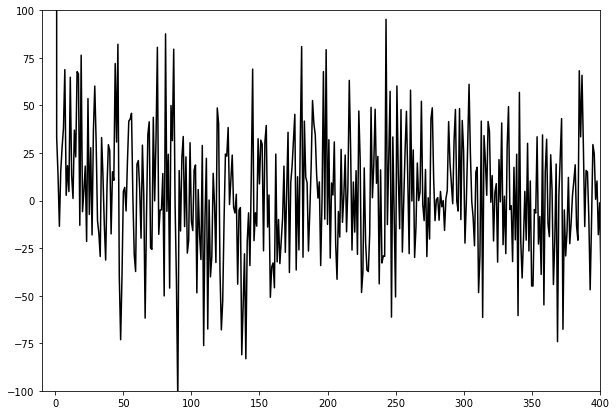

In [356]:
x = np.arange(len(sss),0,-1)
plt.figure(figsize=(10,7))
plt.plot(sp.signal.correlate(sss,sss,mode='full')[len(sss)-1:]/x,'k-')
# plt.yscale('symlog')
plt.xlim(-10,400)
plt.ylim(-100,100)
# plt.plot(sp.signal.correlate(sss,sss,mode='valid')[len(sss)//2:])
# plt.plot(sp.signal.correlate(sss,sss,mode='same')[len(sss)//2:])

In [297]:
Max=10
def autocor_full(arr):
#     arr = arr_in.to_dask_array(lengths=True)
    autocor = dask.array.array(sp.zeros(Len-2*Max+1))
#     autocor_unc = sp.zeros(Len-2*Max+1)
    for tau in range(Len-2*Max+1):
        if tau % 1000 == 0:
            print(tau/(Len-2*Max+1),'\n\n\n')
        skip = (Len-tau-1)//(Max-2)
        autocor[tau] = arr.autocorr(tau, split_every=100)
#         one = arr.loc[::skip]
#         two = arr.shift(tau).loc[::skip]
#         temp = one.mul(two).dropna()
#         autocor[tau] = temp.mean().compute()
#         autocor_unc[tau] = temp.sem(split_every=2).compute()
#     print(Len-2*Max+1, 'of', Len-Min)
#     for tau in range(Len-2*Max+1, Len-Max):
#         temp = np.array([arr[i]*arr[i+tau] for i in np.arange(0, Max)])
#         autocor[tau] = np.mean(temp)
#         autocor_unc[tau] = np.sem(temp)
#     print(Len-Max, 'of', Len-Min)
#     for tau in range(Len-Max, Len-Min):
#         temp = np.array([arr[i]*arr[i+tau] for i in np.arange(0, Len-Min)])
#         autocor[tau] = np.mean(temp)
#         autocor_unc[tau] = np.sem(tep)
    return(autocor)

In [298]:
Len=len(stress)
print(Len)
Max = 1000
func = autocor_full(stress)

98001
0.0 





<ipython-input-297-61e1947cebe9>:4: DeprecationWarning: scipy.zeros is deprecated and will be removed in SciPy 2.0.0, use numpy.zeros instead
  autocor = dask.array.array(sp.zeros(Len-2*Max+1))
/usr/local/anaconda3/lib/python3.8/site-packages/dask/dataframe/multi.py:1094: UserWarning: Concatenating dataframes with unknown divisions.
We're assuming that the indexes of each dataframes are 
 aligned. This assumption is not generally safe.
  warnings.warn(


NotImplementedError: Item assignment with <class 'int'> not supported

In [256]:
func.compute()

0.009907244958163574

In [81]:
stress.shift(2).dropna().loc[::-10].compute()

98000     -0.563239
97990   -115.063685
97980    -40.185841
97970     21.746808
97960    181.473740
            ...    
140       18.471122
130      -35.768331
120      -16.332455
110      -23.997686
100       18.600166
Length: 9791, dtype: float64

In [217]:
tau = 2
skip = (Len-tau-1)//(Max-2)




0.00439911886946705

In [234]:
%%timeit
one = stress.shift(2).loc[::10]
two = stress.loc[::10]
one.mul(two).dropna().mean().compute()

206 ms ± 18.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [235]:
%%timeit

stress.mul(stress.shift(2)).dropna().loc[::10].mean().compute()

199 ms ± 14.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [220]:
stress.to_dask_array(lengths=True)[1].mean()

dask.array<mean_agg-aggregate, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>

0    -44.400124
1    -17.122554
2     62.634473
3   -161.451705
4   -104.300990
dtype: float64

In [379]:
dask.array([1234,3])

TypeError: 'module' object is not callable

In [357]:
stress.to_dask_array()

dask.array<values, shape=(nan,), dtype=float64, chunksize=(nan,), chunktype=numpy.ndarray>